# **Tutorial 4 Spatial multi-omics diagonal integration without histology anchor on Human Colon**

Our data are organized as follows: the `datasets` directory stores the raw datasets, the `inputs` directory contains input data such as the pre-extracted H&E embeddings and filtered cell indices, and the `outputs` directory stores the model outputs.

```
our_model/
│
├── datasets/                  # The datasets
│   ├── ...                   
│
├── inputs/                    # The inputs
│   ├── ...
│
├── outputs/                   # The outputs
│   ├── ... 
```

In [5]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm import tqdm
import SpaWeaver as sw
import matplotlib.pyplot as plt
import torch.multiprocessing as mp

## 1. Prepare the dataset

### [Download](https://spatch.pku-genomics.org/#/dataset/xenium) the COAD dataset of SPATCH. Considering the large size of the raw dataset, we provide the related data. These data should be organized into the following directory structure:

```
datasets/
├── SPATCH
    ├── Xenium/                  # The 1st slice
    │   ├── COAD_RNA.h5ad                    
    │
    ├── CODEX/                   # The 2nd slice
    │   ├── COAD_Protein.h5ad
```

For convenience, we provide image embeddings extracted using the H&E foundation model UNI, along with the corresponding cell indices within the sequenced regions. We also provide the gene panel selected based on Moran’s I and coarse-grained cell type annotations derived from marker genes. These data are stored in the `inputs` directory, where each subdirectory contains the following files.

**he_emb**: COAD_RNA.npy and COAD_Protein.npy

**cell_filter**: COAD_RNA.npy and COAD_Protein.npy

**panel**: Xenium_moransi.csv

**annotation**: COAD_CODEX_celltype.csv

```
inputs/
├── cell_filter/                  # Stores the filtered cell indices
│   ├── COAD_RNA.npy              # RNA              
│   ├── COAD_Protein.npy          # Protein
│
├── he_emb/                       # Store the extracted H&E image embeddings.
│   ├── COAD_RNA_UNI.npy          # RNA                 
│   ├── COAD_Protein_UNI.npy      # Protein
│
├── panel/                        # Store the pre-defined panels.
│   ├── Xenium_moransi.csv
│
├── annotations/                  # Store the celltype annotations.
│   ├── COAD_CODEX_celltype.csv
```

**We have uploaded the associated data to Zenodo, which can be accessed through this <a href="https://zenodo.org/" style="color:red;">link</a>**.

## 2. Run the model

### 2.1 Define the arguments

In [6]:
sys.argv = ["script", "--epoch", "2000", "--hops", "0"]
args = sw.args.build_args()
print(args)

Namespace(seed=0, device=0, optimizer='adam', load_model=False, hops=0, pe_dim=128, hidden_dim=128, n_layers=1, n_heads=2, dropout=0.1, attention_dropout=0.1, activation='elu', epoch=2000, batch_size=4096, loss_fn='mse', lr=0.001, weight_decay=0, sample_name1='Human_Breast_Cancer_Rep1', root_path1='./datasets/Human_Breast_Cancer_Rep1/', sample_name2='Human_Breast_Cancer_Rep2', root_path2='./datasets/Human_Breast_Cancer_Rep2/', save=True, save_tag='fig2', output_folder='./outputs/', image_encoder='uni', img_batch_size=64, num_neighbors=7, scale=0.363788, cell_diameter=-1, resolution=64, mmd_weight=0.01)


The parameters defined above can be adjusted according to your experimental settings.

In [7]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3' # Specify the visible GPUs, as multi-GPU training is utilized in the following code.
world_size = 3 # the number of gpus

args.root_path1 = './datasets/SPATCH/Xenium/'
args.root_path2 = './datasets/SPATCH/CODEX/'
args.output_folder = './outputs/'

if not os.path.exists("./outputs/"):
    os.makedirs("./outputs/")

args.output_folder = './outputs/'
args.save_tag = 'fig5'

if not os.path.exists("./outputs/model/fig5"):
    os.makedirs("./outputs/model/fig5")

if not os.path.exists("./outputs/result/fig5"):
    os.makedirs("./outputs/result/fig5")

sw.utils.set_random_seed(args.seed)

print("complete!")

complete!


### 2.2 Panel partitioning

In [8]:
meta_root = './inputs/'
moransi_df = pd.read_csv('./inputs/panel/Xenium_moransi.csv', index_col=0)
svgs = moransi_df.sort_values(by = 'Morans\'I', ascending=False).index[:500].tolist()
anno_key = 'annotation'

print("complete!")

complete!


###  2.3 Gene expression preprocessing

#### 2.3.1 Loading Xenium data

In [9]:
print("📥 Loading Xenium data...")
adata1 = sw.pp.read_h5ad('./datasets/SPATCH/Xenium/COAD_RNA.h5ad')
adata1 = sw.pp.load_he_emb(adata1, meta_root, 'COAD_RNA')
print("complete!")

📥 Loading Xenium data...
complete!


Due to the presence of stripe-like noise in the H&E images, we add sinusoidal filter applied to H&E embeddings to the routine quality control procedure :

In [10]:
emb, spatial = adata1.obsm['he'].copy(), adata1.obsm['spatial'].copy()
for _ in tqdm(range(5), desc="🧼 Removing artifacts"):
    emb = sw.utils.remove_sinusoidal_component(emb, spatial[:, 1], min_peak_freq=0.001, bin_width=10)
    emb = sw.utils.remove_sinusoidal_component(emb, spatial[:, 0], min_peak_freq=0.001, bin_width=10)
adata1.obsm['he'] = emb

adata1 = adata1[adata1.obs['high_quality']==1]
sc.pp.filter_genes(adata1, min_cells=1)
adata1.var["mt"] = adata1.var_names.str.startswith("mt-")
adata1 = adata1[:, ~adata1.var["mt"]]

print("complete!")

🧼 Removing artifacts: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:50<00:00, 34.08s/it]


complete!


#### 2.3.2 Loading CODEX data

In [11]:
print("📥 Loading CODEX data...")
adata2 = sw.pp.read_h5ad('./datasets/SPATCH/CODEX/COAD_Protein.h5ad')
adata2 = sw.pp.load_he_emb(adata2, meta_root, 'COAD_Protein')
print("complete!")

📥 Loading CODEX data...
complete!


#### 2.3.3 Adding annotation

In [12]:
adata1.obs['annotation'][adata1.obs['annotation'] == 'Monocyte'] = 'Macrophage'
adata1.obs['annotation'] = adata1.obs['annotation'].astype(str).astype('category')
celltype_list = ['Epithelial', 'Endothelial', 'Fibroblast', 'B', 'CD4T', 'CD8T', 'Tprolif', 'Macrophage', 'cDC2', 'mregDC']
selection1 = np.array([False]*adata1.n_obs)
for celltype in celltype_list:
    selection1 = selection1 + (adata1.obs['annotation'].values == celltype)
adata1 = adata1[selection1]

adata2.obs[anno_key] = pd.read_csv('./inputs/annotations/COAD_CODEX_celltype.csv', index_col=0).loc[adata2.obs_names].values.squeeze()
adata2.obs[anno_key] = adata2.obs[anno_key].astype('category').values

print("complete!")

complete!


#### 2.3.4 Preprocessing RNA

In [13]:
print("🧼 Preprocessing RNAs...")
coding_genes = adata2.uns['Coding_genes'].values()
all_coding_genes = set()
for arr in coding_genes:
    all_coding_genes.update(arr) 

CD11c_unique = ['FCGBP', 'PPP1R1B', 'MUC4', 'KRT20', 'DUOX2', 'MUC5B', 'ABO', 'FUT3', ]
panelA = list(set(svgs) - all_coding_genes - set(CD11c_unique))

adata1 = adata1[:, panelA].copy()
adata1 = sw.pp.preprocess_rna(adata1)

print("complete!")

🧼 Preprocessing RNAs...
complete!


#### 2.3.5 Preprocessing Protein

In [14]:
adata2 = sw.pp.preprocess_protein(adata2)
print(adata1, adata2)

AnnData object with n_obs × n_vars = 305329 × 492
    obs: 'codex_common', 'annotation', 'spatial_cluster', 'high_quality'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt'
    uns: 'CODEX resolution', 'DAPI resolution', 'H&E resolution', 'log1p'
    obsm: 'spatial', 'he'
    layers: 'raw' AnnData object with n_obs × n_vars = 266530 × 16
    obs: 'codex_common', 'annotation', 'spatial_cluster'
    uns: 'CODEX resolution', 'Coding_genes'
    obsm: 'spatial', 'he'


### 2.4 Build graphs, datasets, and models

#### 2.4.1 Building graphs

In [11]:
print("🕸️ Building graphs (KNN)...")
H1 = sw.pp.build_graph(adata1.obsm['spatial'], graph_type='knn', num_neighbors=args.num_neighbors, return_type='csr', apply_normalize='both')
H2 = sw.pp.build_graph(adata2.obsm['spatial'], graph_type='knn', num_neighbors=args.num_neighbors, return_type='csr', apply_normalize='both')

args.device = 'cpu'
print("🧩 Aggregating neighborhood features...")
node_HE_fea1 = sw.utils.re_features(H1, adata1.obsm['he'], args.hops, device=args.device)
node_HE_fea2 = sw.utils.re_features(H2, adata2.obsm['he'], args.hops, device=args.device)
adata1.obsm['he_sp'], adata2.obsm['he_sp'] = node_HE_fea1, node_HE_fea2

domain2idx_map = {anno: i for i, anno in enumerate(adata1.obs[anno_key].unique())}
anno1 = adata1.obs[anno_key].values.map(domain2idx_map)
anno2 = adata2.obs[anno_key].values.map(domain2idx_map)
print(anno2)

🕸️ Building graphs (KNN)...
🧩 Aggregating neighborhood features...
[2, 6, 2, 2, 2, ..., 2, 2, 2, 2, 2]
Length: 266530
Categories (10, int64): [5, 0, 3, 7, ..., 6, 4, 9, 8]


#### 2.4.2 Building model

In [12]:
print("🧠 Building model...")
model_1 = sw.model.transformerModel(hops=args.hops,
                           input_dim=args.hidden_dim,
                           n_layers=args.n_layers,
                           num_heads=args.n_heads,
                           hidden_dim=args.hidden_dim,
                           dropout_rate=args.dropout,
                           attention_dropout_rate=args.attention_dropout)

mlp_1 = sw.model.OneLayerMLP(adata2.obsm['he_sp'].shape[-1], args.hidden_dim) 
reg_1 = sw.model.OneLayerMLP(args.hidden_dim + 16, adata1.n_vars)
reg_2 = sw.model.OneLayerMLP(args.hidden_dim + 16, adata2.n_vars)
anno_emb = torch.nn.Embedding(len(domain2idx_map), 16)
models = torch.nn.ModuleList([model_1, mlp_1, reg_1, reg_2, anno_emb])

🧠 Building model...


### 2.5 Train the model

Training function with GPU acceleration

In [13]:
print("🚀 Training...")
os.environ['MASTER_ADDR'] = 'localhost'
os.environ['MASTER_PORT'] = str(sw.utils.find_free_port())
mp.spawn(sw.PT.train_Multi_Omics, args=(world_size, args, adata1, adata2, models, anno1, anno2), nprocs=world_size, join=True)

🚀 Training...
Using port: 29500


🧠 Training: 100%|██████████| 2000/2000 [1:37:41<00:00,  2.93s/it]


💾 Saving checkpoint...


### 2.6 Test the model

In [14]:
print("🧪 Running inference...")
checkpoint = torch.load(f'{args.output_folder}model/{args.save_tag}/models.pt', map_location='cpu')
model_1.load_state_dict(checkpoint['model_1'])
mlp_1.load_state_dict(checkpoint['mlp_1'])
reg_1.load_state_dict(checkpoint['reg_1'])
reg_2.load_state_dict(checkpoint['reg_2'])
anno_emb.load_state_dict(checkpoint['anno_emb'])

model_1.eval()
mlp_1.eval()
reg_1.eval()
reg_2.eval()
anno_emb.eval()

he1, he2 = torch.Tensor(adata1.obsm['he_sp']), torch.Tensor(adata2.obsm['he_sp'])
anno1, anno2 = torch.LongTensor(anno1), torch.LongTensor(anno2)
he1_map, he2_map = model_1(mlp_1(he1)), model_1(mlp_1(he2))
anno_emb1, anno_emb2 = anno_emb(anno1), anno_emb(anno2)
emb1, emb2 = torch.concat([he1_map, anno_emb1], dim=1), torch.concat([he2_map, anno_emb2], dim=1)
panelA1 = reg_1(emb1).detach().cpu().numpy()
panelA2 = reg_1(emb2).detach().cpu().numpy()
panelB1 = reg_2(emb1).detach().cpu().numpy()
panelB2 = reg_2(emb2).detach().cpu().numpy()

if args.save:
    print("💾 Saving outputs...")
    obs1, obs2 = adata1.obs_names, adata2.obs_names
    var1, var2 = adata1.var_names, adata2.var_names

    dfA1 = pd.DataFrame(panelA1, index=obs1, columns=var1)
    dfA2 = pd.DataFrame(panelA2, index=obs2, columns=var1)
    dfB1 = pd.DataFrame(panelB1, index=obs1, columns=var2)
    dfB2 = pd.DataFrame(panelB2, index=obs2, columns=var2)
    dfA1.to_csv(f'{args.output_folder}result/{args.save_tag}/A1.csv')
    dfA2.to_csv(f'{args.output_folder}result/{args.save_tag}/A2.csv')
    dfB1.to_csv(f'{args.output_folder}result/{args.save_tag}/B1.csv')
    dfB2.to_csv(f'{args.output_folder}result/{args.save_tag}/B2.csv')
    np.save(f'{args.output_folder}result/{args.save_tag}/HE1.npy', emb1.detach().cpu().numpy())
    np.save(f'{args.output_folder}result/{args.save_tag}/HE2.npy', emb2.detach().cpu().numpy())
    print(f"✅ Outputs saved to {args.output_folder}result/{args.save_tag}/**.")

🧪 Running inference...
💾 Saving outputs...
✅ Outputs saved to ./outputs/result/fig5/**.


## 3. Evaluation

In [15]:
file_root = f'{args.output_folder}result/{args.save_tag}/'
B1 = pd.read_csv(file_root + 'B1.csv', index_col=0)
A2 = pd.read_csv(file_root + 'A2.csv', index_col=0)
B1.index, A2.index = B1.index.astype(str), A2.index.astype(str)
obs1, obs2, var1, var2 = B1.index, A2.index, A2.columns, B1.columns

In [16]:
adata1 = sw.pp.read_h5ad('./datasets/SPATCH/Xenium/COAD_RNA.h5ad')[obs1]
adata2 = sw.pp.read_h5ad('./datasets/SPATCH/CODEX/COAD_Protein.h5ad')[obs2]
adata1 = sw.pp.preprocess_adata(adata1, selected_genes=var1)
adata2 = sw.pp.preprocess_protein(adata2)

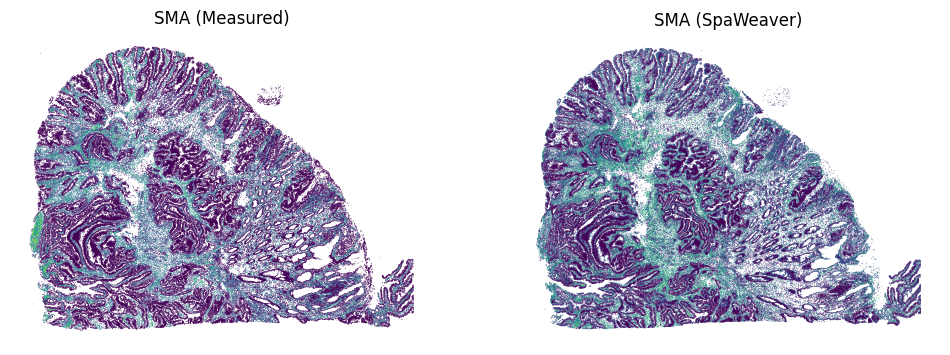

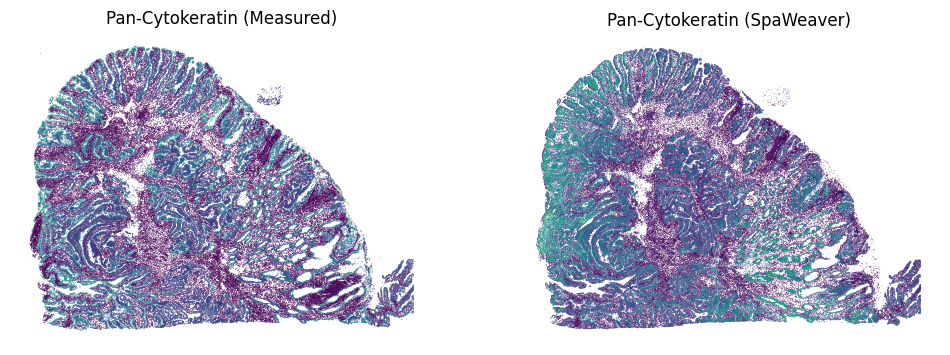

In [17]:
spatial1 = adata1.obsm['spatial']
spatial2 = adata2.obsm['spatial']

protein_list = ['SMA', 'Pan-Cytokeratin']
for protein in protein_list:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    value = adata2[:, protein].X.squeeze()
    order = np.argsort(value)
    plt.scatter(spatial2[order, 0], spatial2[order, 1], c=value[order], s=0.2, vmin=0, edgecolor='none', rasterized=True)
    plt.gca().set_aspect(1)
    plt.axis('off')
    plt.title(protein + ' (Measured)')

    plt.subplot(1, 2, 2)
    value = B1[protein].values.squeeze()
    order = np.argsort(value)
    plt.scatter(spatial1[order, 0], spatial1[order, 1], c=value[order], s=0.2, vmin=0, edgecolor='none', rasterized=True)
    plt.gca().set_aspect(1)
    plt.axis('off')
    plt.title(protein + ' (SpaWeaver)')
    
    plt.show()